# Crypto Market Analysis

## Problem Statement

This project investigates how historical trader activity and performance relate to Bitcoin market sentiment. This notebook focuses on loading the two source datasets, understanding their schemas, and documenting data-quality observations, values are cleaned, converted, merged, or visualized in this notebook.

## 1. Import Libraries

In [1]:
from pathlib import Path
import sys

import pandas as pd

project_root = Path.cwd()
if not (project_root / "src").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.loader import (
    get_dataset_summary,
    load_fear_greed_data,
    load_historical_data,
)
from src.preprocessing import (
    clean_fear_greed_data,
    clean_historical_data,
    get_cleaning_summary,
    merge_datasets,
    save_processed_dataset,
    validate_merge,
)

## 2. Load Datasets

The reusable loader functions resolve the configured raw-data paths and validate each expected schema.

In [2]:
historical_data = load_historical_data()
fear_greed_data = load_fear_greed_data()

print("Historical trader data loaded:", historical_data.shape)
print("Fear & Greed Index data loaded:", fear_greed_data.shape)

Historical trader data loaded: (211224, 16)
Fear & Greed Index data loaded: (2644, 4)


## 3. Dataset Overview

In [3]:
historical_summary = get_dataset_summary(historical_data)
fear_greed_summary = get_dataset_summary(fear_greed_data)

def overview_table(summary: dict) -> pd.DataFrame:
    """Build a readable schema and memory-usage table."""
    return pd.DataFrame(
        {
            "dtype": summary["dtypes"],
            "memory_bytes": summary["memory_usage_by_column_bytes"],
        }
    )

### Historical Trader Data

In [4]:
print("Shape:", historical_summary["shape"])
print("Columns:", historical_summary["columns"])
print("Total memory usage (bytes):", historical_summary["memory_usage_bytes"])
print(overview_table(historical_summary).to_string())
print("\nFirst five rows:")
print(historical_data.head().to_string())
print("\nLast five rows:")
print(historical_data.tail().to_string())

Shape: (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Total memory usage (bytes): 107159892
                    dtype  memory_bytes
Account            object      19221384
Coin               object      11192873
Execution Price   float64       1689792
Size Tokens       float64       1689792
Size USD          float64       1689792
Side               object      11092176
Timestamp IST      object      13729560
Start Position    float64       1689792
Direction          object      12213655
Closed PnL        float64       1689792
Transaction Hash   object      24290760
Order ID            int64       1689792
Crossed              bool        211224
Fee               float64       1689792
Trade ID          float64       1689792
Timestamp         float64       1689792

First five rows:
                        

### Fear & Greed Index Data

In [5]:
print("Shape:", fear_greed_summary["shape"])
print("Columns:", fear_greed_summary["columns"])
print("Total memory usage (bytes):", fear_greed_summary["memory_usage_bytes"])
print(overview_table(fear_greed_summary).to_string())
print("\nFirst five rows:")
print(fear_greed_data.head().to_string())
print("\nLast five rows:")
print(fear_greed_data.tail().to_string())

Shape: (2644, 4)
Columns: ['timestamp', 'value', 'classification', 'date']
Total memory usage (bytes): 347383
                 dtype  memory_bytes
timestamp        int64         21152
value            int64         21152
classification  object        148951
date            object        155996

First five rows:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Last five rows:
       timestamp  value classification        date
2639  1745818200     54        Neutral  2025-04-28
2640  1745904600     60          Greed  2025-04-29
2641  1745991000     56          Greed  2025-04-30
2642  1746077400     53        Neutral  2025-05-01
2643  1746163800     67          Greed  2025-05-02


## Data Quality Assessment

In [6]:
def quality_table(summary: dict) -> pd.DataFrame:
    """Combine missing-value and cardinality counts by column."""
    return pd.DataFrame(
        {
            "missing_values": summary["missing_values"],
            "unique_values_including_missing": summary["unique_values"],
        }
    )

print("Historical duplicate rows:", historical_summary["duplicate_rows"])
print(quality_table(historical_summary).to_string())
print("\nFear & Greed duplicate rows:", fear_greed_summary["duplicate_rows"])
print(quality_table(fear_greed_summary).to_string())

Historical duplicate rows: 0
                  missing_values  unique_values_including_missing
Account                        0                               32
Coin                           0                              246
Execution Price                0                            60162
Size Tokens                    0                            59304
Size USD                       0                           118493
Side                           0                                2
Timestamp IST                  0                            27977
Start Position                 0                           196923
Direction                      0                               12
Closed PnL                     0                            90720
Transaction Hash               0                           101184
Order ID                       0                            50555
Crossed                        0                                2
Fee                            0               

### Numeric Summary Statistics

In [7]:
print("Historical numeric summary:")
print(historical_data.describe(include="number").T.to_string())
print("\nFear & Greed numeric summary:")
print(fear_greed_data.describe(include="number").T.to_string())

Historical numeric summary:
                    count          mean           std           min           25%           50%           75%           max
Execution Price  211224.0  1.141472e+04  2.944765e+04  4.530000e-06  4.854700e+00  1.828000e+01  1.015800e+02  1.090040e+05
Size Tokens      211224.0  4.623365e+03  1.042729e+05  8.740000e-07  2.940000e+00  3.200000e+01  1.879025e+02  1.582244e+07
Size USD         211224.0  5.639451e+03  3.657514e+04  0.000000e+00  1.937900e+02  5.970450e+02  2.058960e+03  3.921431e+06
Start Position   211224.0 -2.994625e+04  6.738074e+05 -1.433463e+07 -3.762311e+02  8.472793e+01  9.337278e+03  3.050948e+07
Closed PnL       211224.0  4.874900e+01  9.191648e+02 -1.179901e+05  0.000000e+00  0.000000e+00  5.792797e+00  1.353291e+05
Order ID         211224.0  6.965388e+10  1.835753e+10  1.732711e+08  5.983853e+10  7.442939e+10  8.335543e+10  9.014923e+10
Fee              211224.0  1.163967e+00  6.758854e+00 -1.175712e+00  1.612094e-02  8.957750e-02  3.93811

### Categorical Summaries

In [8]:
def categorical_summary(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Describe text, category, and boolean columns without conversion."""
    categorical_columns = dataframe.select_dtypes(
        include=["object", "string", "category", "bool"]
    ).columns
    return dataframe[categorical_columns].describe().T

print("Historical categorical summary:")
print(categorical_summary(historical_data).to_string())
print("\nFear & Greed categorical summary:")
print(categorical_summary(fear_greed_data).to_string())

Historical categorical summary:
                   count  unique                                                                 top    freq
Account           211224      32                          0xbee1707d6b44d4d52bfe19e41f8a828645437aab   40184
Coin              211224     246                                                                HYPE   68005
Side              211224       2                                                                SELL  108528
Timestamp IST     211224   27977                                                    14-02-2025 00:31     441
Direction         211224      12                                                           Open Long   49895
Transaction Hash  211224  101184  0x0000000000000000000000000000000000000000000000000000000000000000    9032
Crossed           211224       2                                                                True  128403

Fear & Greed categorical summary:
               count unique         top freq
classification  

## Date Validation

The following cells inspect stored values and inferred data types only. They deliberately do not parse or convert dates.

In [9]:
print("Historical Timestamp dtype:", historical_data["Timestamp"].dtype)
print("Historical Timestamp unique values:", historical_data["Timestamp"].nunique(dropna=False))
print(historical_data["Timestamp"].value_counts(dropna=False).sort_index().to_string())

print("\nHistorical Timestamp IST dtype:", historical_data["Timestamp IST"].dtype)
print("Historical Timestamp IST unique values:", historical_data["Timestamp IST"].nunique(dropna=False))
print("First five values:", historical_data["Timestamp IST"].head().tolist())
print("Last five values:", historical_data["Timestamp IST"].tail().tolist())

print("\nFear & Greed date dtype:", fear_greed_data["date"].dtype)
print("Fear & Greed date unique values:", fear_greed_data["date"].nunique(dropna=False))
print("First five values:", fear_greed_data["date"].head().tolist())
print("Last five values:", fear_greed_data["date"].tail().tolist())

Historical Timestamp dtype: float64
Historical Timestamp unique values: 7
Timestamp
1.680000e+12         3
1.700000e+12      1045
1.710000e+12      6962
1.720000e+12      7141
1.730000e+12     35241
1.740000e+12    133871
1.750000e+12     26961

Historical Timestamp IST dtype: object
Historical Timestamp IST unique values: 27977
First five values: ['02-12-2024 22:50', '02-12-2024 22:50', '02-12-2024 22:50', '02-12-2024 22:50', '02-12-2024 22:50']
Last five values: ['25-04-2025 15:35', '25-04-2025 15:35', '25-04-2025 15:35', '25-04-2025 15:35', '25-04-2025 15:35']

Fear & Greed date dtype: object
Fear & Greed date unique values: 2644
First five values: ['2018-02-01', '2018-02-02', '2018-02-03', '2018-02-04', '2018-02-05']
Last five values: ['2025-04-28', '2025-04-29', '2025-04-30', '2025-05-01', '2025-05-02']


## Initial Observations

- The historical trader dataset contains **211,224 rows and 16 columns**; the Fear & Greed dataset contains **2,644 rows and 4 columns**.
- Pandas detects **no missing values and no fully duplicated rows** in either raw dataset.
- The trader dataset contains 32 accounts and 246 coins. Several fields have high cardinality, including `Start Position` (196,923 distinct values), `Fee` (138,802), `Size USD` (118,493), and `Transaction Hash` (101,184).
- `Timestamp IST` is loaded as text and has 27,977 distinct values. The numeric `Timestamp` field is loaded as `float64` but has only seven distinct values, so its precision and intended meaning require validation before it is used.
- The Fear & Greed `date` field is loaded as text, while its `timestamp` field is loaded as an integer. Each has 2,644 distinct values.
- A calendar date derived from `Timestamp IST` and the Fear & Greed `date` field appear to be potential future merge keys. Their formats, time zones, ranges, and overlap must be validated before any merge.
- Likely Phase 2 preprocessing requirements include explicit datetime parsing and validation of timestamp precision. No preprocessing has been performed in this phase.

# 4. Data Cleaning

Exact duplicate rows are removed, source columns are standardized to snake_case, numeric and datetime fields are converted, and a normalized `trade_date` is created. Identifier duplication is reported separately because repeated order IDs and transaction hashes may represent multiple trade fills rather than duplicate records.

In [10]:
cleaned_historical_data = clean_historical_data(historical_data)
cleaned_fear_greed_data = clean_fear_greed_data(fear_greed_data)

historical_cleaning_summary = get_cleaning_summary(
    historical_data,
    cleaned_historical_data,
    identifier_columns=("order_id", "transaction_hash"),
)
fear_greed_cleaning_summary = get_cleaning_summary(
    fear_greed_data,
    cleaned_fear_greed_data,
)

In [11]:
cleaning_validation = pd.DataFrame(
    [
        {
            "dataset": "Historical trader data",
            "rows_before": historical_cleaning_summary["rows_before"],
            "rows_after": historical_cleaning_summary["rows_after"],
            "rows_removed": historical_cleaning_summary["rows_removed"],
            "missing_before": historical_cleaning_summary["missing_values_before"],
            "missing_after": historical_cleaning_summary["missing_values_after"],
        },
        {
            "dataset": "Fear & Greed Index data",
            "rows_before": fear_greed_cleaning_summary["rows_before"],
            "rows_after": fear_greed_cleaning_summary["rows_after"],
            "rows_removed": fear_greed_cleaning_summary["rows_removed"],
            "missing_before": fear_greed_cleaning_summary["missing_values_before"],
            "missing_after": fear_greed_cleaning_summary["missing_values_after"],
        },
    ]
).set_index("dataset")
print(cleaning_validation.to_string())

                         rows_before  rows_after  rows_removed  missing_before  missing_after
dataset                                                                                      
Historical trader data        211224      211224             0               0              0
Fear & Greed Index data         2644        2644             0               0              0


## Column Transformations

In [12]:
print("Historical columns after cleaning:")
print(historical_cleaning_summary["columns_after"])
print("\nHistorical data types after cleaning:")
print(pd.Series(historical_cleaning_summary["dtypes_after"]).to_string())
print("\nFear & Greed columns after cleaning:")
print(fear_greed_cleaning_summary["columns_after"])
print("\nFear & Greed data types after cleaning:")
print(pd.Series(fear_greed_cleaning_summary["dtypes_after"]).to_string())

Historical columns after cleaning:
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'trade_date']

Historical data types after cleaning:
account                          object
coin                             object
execution_price                 float64
size_tokens                     float64
size_usd                        float64
side                             object
timestamp_ist            datetime64[ns]
start_position                  float64
direction                        object
closed_pnl                      float64
transaction_hash                 object
order_id                          int64
crossed                            bool
fee                             float64
trade_id                        float64
timestamp           datetime64[ns, UTC]
trade_date               datetime64[ns]

Fear & Greed columns

## Identifier Duplicate Validation

These counts describe repeated identifiers after exact duplicate rows have been removed. The rows are retained because identifier repetition alone does not establish that the trade records are duplicates.

In [13]:
identifier_validation = pd.DataFrame(
    historical_cleaning_summary["identifier_duplicates"]
).T
print(identifier_validation.to_string())

                  duplicate_rows  duplicate_values
order_id                  181845             21176
transaction_hash          126734             16694


# 5. Merge Process

The cleaned historical dataset is the left-side dataset. Fear & Greed fields are prefixed to preserve their source and the datasets are joined on `trade_date`.

In [14]:
merged_data = merge_datasets(
    cleaned_historical_data,
    cleaned_fear_greed_data,
)
merge_validation = validate_merge(cleaned_historical_data, merged_data)

# Validation

In [15]:
merge_validation_table = pd.DataFrame(
    {"value": merge_validation}
)
print(merge_validation_table.to_string())

unmatched_dates = (
    merged_data.loc[
        merged_data["fear_greed_classification"].isna(),
        "trade_date",
    ]
    .value_counts()
    .sort_index()
)
print("\nUnmatched trade rows by date:")
print(unmatched_dates.to_string())

                                  value
rows_before_merge           211224.0000
rows_after_merge            211224.0000
row_difference                   0.0000
matched_sentiment_rows      211218.0000
missing_sentiment_rows           6.0000
merge_success_rate_percent      99.9972

Unmatched trade rows by date:
trade_date
2024-10-26    6


## Merged Dataset Preview

In [16]:
print("Merged shape:", merged_data.shape)
print(merged_data.head().to_string())

Merged shape: (211224, 21)
                                      account  coin  execution_price  size_tokens  size_usd side       timestamp_ist  start_position direction  closed_pnl                                                    transaction_hash     order_id  crossed       fee      trade_id                 timestamp trade_date  fear_greed_timestamp  fear_greed_value fear_greed_classification fear_greed_date
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49  52017706630     True  0.345404  8.950000e+14 2024-10-27 03:33:20+00:00 2024-12-02          1.733117e+09              80.0             Extreme Greed      2024-12-02
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy         0.0  0xec09451986a1874e3a980418412fcd0201f500c

## Save Processed Dataset

In [17]:
processed_dataset_path = save_processed_dataset(merged_data)
print("Processed dataset saved to:", processed_dataset_path)

Processed dataset saved to: C:\Users\taman\Desktop\crypto-market-analysis\data\processed\merged_dataset.csv


# 6. Exploratory Data Analysis

This section uses only the saved merged dataset. It summarizes distributions and relationships without predictive modeling or causal interpretation.

In [18]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
from matplotlib import MatplotlibDeprecationWarning
import pandas as pd
import seaborn as sns

project_root = Path.cwd()
if not (project_root / "src").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import MERGED_DATASET_PATH

eda_data = pd.read_csv(
    MERGED_DATASET_PATH,
    low_memory=False,
    parse_dates=["timestamp_ist", "trade_date", "fear_greed_date"],
)

SENTIMENT_ORDER = [
    "Extreme Fear",
    "Fear",
    "Neutral",
    "Greed",
    "Extreme Greed",
]
SENTIMENT_COLORS = [
    "#9B2C2C",
    "#D97706",
    "#718096",
    "#2F855A",
    "#276749",
]
SENTIMENT_PALETTE = dict(zip(SENTIMENT_ORDER, SENTIMENT_COLORS))
PRIMARY_COLOR = "#2B6CB0"
NEGATIVE_COLOR = "#C05640"
warnings.filterwarnings(
    "ignore",
    message="vert: bool was deprecated",
    category=MatplotlibDeprecationWarning,
)
warnings.filterwarnings(
    "ignore",
    message="The set_bad function will be deprecated",
    category=PendingDeprecationWarning,
)
sns.set_theme(style="whitegrid", context="notebook")

def finish_plot(title: str, x_label: str, y_label: str) -> None:
    """Apply consistent labels and spacing to the active figure."""
    plt.title(title, pad=12, weight="bold")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    sns.despine()
    plt.tight_layout()
    plt.show()

print("EDA dataset loaded:", eda_data.shape)

EDA dataset loaded: (211224, 21)


## Market Sentiment Overview

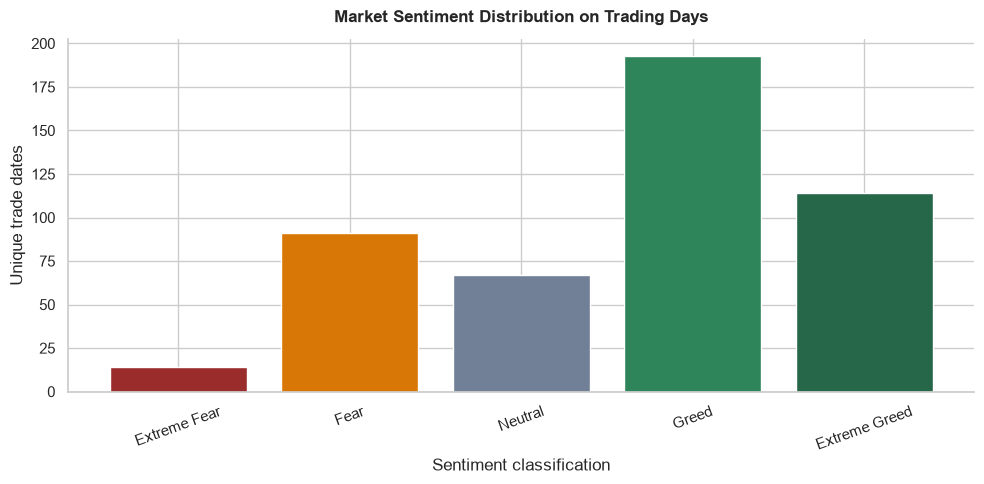

In [19]:
daily_sentiment = (
    eda_data.dropna(subset=["fear_greed_classification"])
    [["trade_date", "fear_greed_value", "fear_greed_classification"]]
    .drop_duplicates(subset=["trade_date"])
    .sort_values("trade_date")
)
sentiment_day_counts = (
    daily_sentiment["fear_greed_classification"]
    .value_counts()
    .reindex(SENTIMENT_ORDER, fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    sentiment_day_counts.index,
    sentiment_day_counts.values,
    color=SENTIMENT_COLORS,
)
ax.tick_params(axis="x", rotation=20)
finish_plot(
    "Market Sentiment Distribution on Trading Days",
    "Sentiment classification",
    "Unique trade dates",
)

**Observation:** Among 479 trade dates with sentiment data, Greed appears most often (193 days, 40.3%), followed by Extreme Greed (114 days, 23.8%). Extreme Fear appears on 14 days (2.9%). Counts use one sentiment record per trade date so high-activity days are not overrepresented.

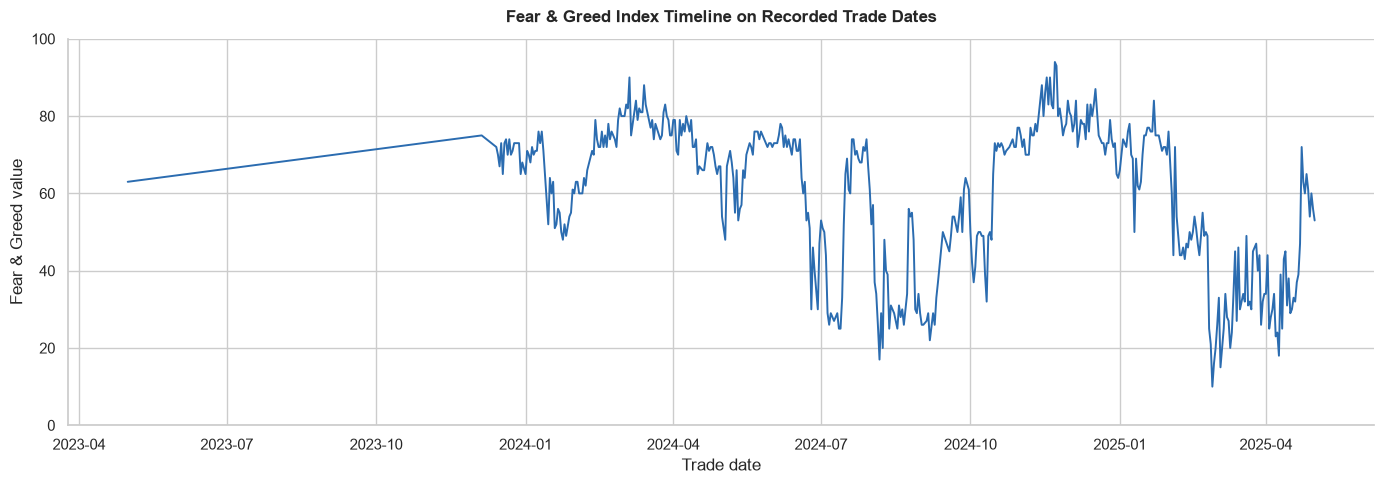

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    daily_sentiment["trade_date"],
    daily_sentiment["fear_greed_value"],
    color=PRIMARY_COLOR,
    linewidth=1.4,
)
ax.set_ylim(0, 100)
finish_plot(
    "Fear & Greed Index Timeline on Recorded Trade Dates",
    "Trade date",
    "Fear & Greed value",
)

**Observation:** The available trade-date timeline runs from May 2023 through May 2025, with recorded sentiment values ranging from 10 to 94. The line includes only dates represented in the merged trade data.

## Trading Behaviour

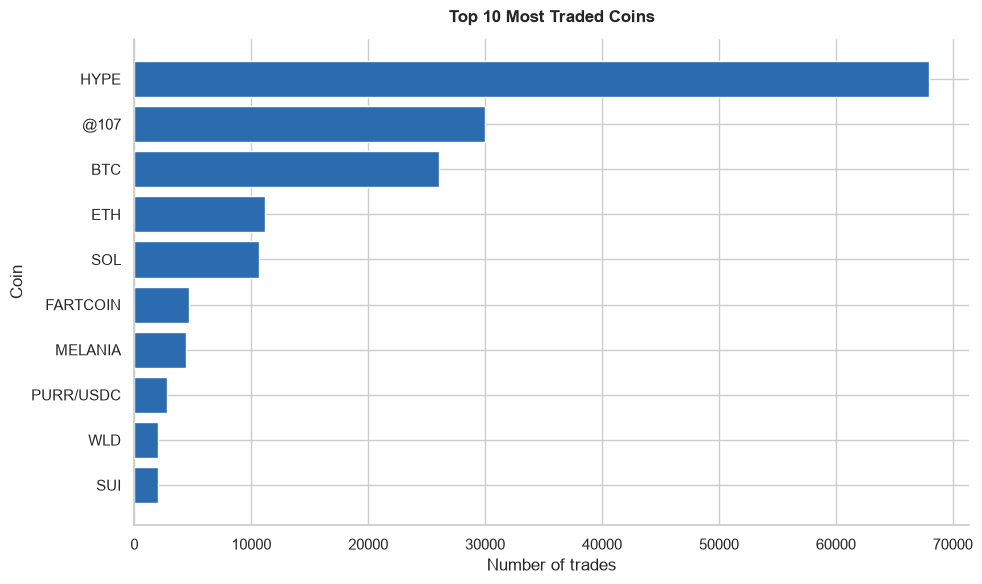

In [21]:
top_coins = eda_data["coin"].value_counts().head(10).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_coins.index, top_coins.values, color=PRIMARY_COLOR)
finish_plot(
    "Top 10 Most Traded Coins",
    "Number of trades",
    "Coin",
)

**Observation:** HYPE has the largest trade count (68,005; 32.2% of all rows), followed by @107 (29,992) and BTC (26,064).

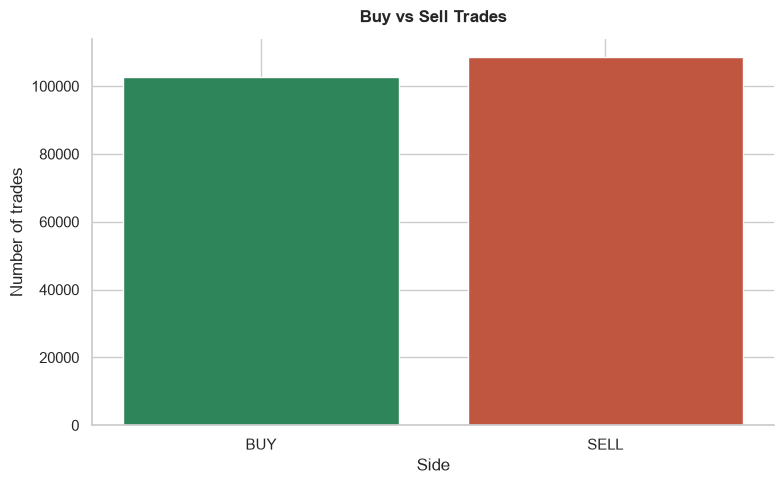

In [22]:
side_counts = eda_data["side"].value_counts().reindex(["BUY", "SELL"])
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(side_counts.index, side_counts.values, color=["#2F855A", "#C05640"])
finish_plot("Buy vs Sell Trades", "Side", "Number of trades")

**Observation:** Sell trades account for 108,528 rows (51.38%) and buy trades for 102,696 (48.62%), a difference of 5,832 trades.

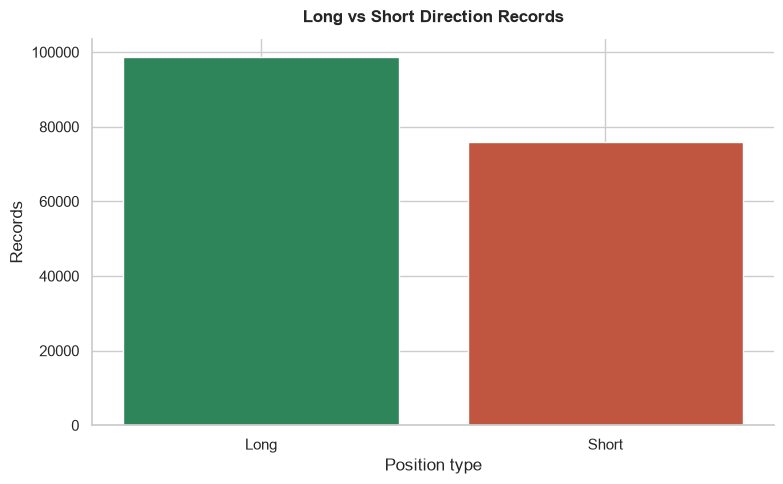

In [23]:
position_type = eda_data["direction"].astype("string").str.extract(
    r"(Long|Short)",
    expand=False,
)
long_short_counts = position_type.value_counts().reindex(["Long", "Short"])
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    long_short_counts.index,
    long_short_counts.values,
    color=["#2F855A", "#C05640"],
)
finish_plot("Long vs Short Direction Records", "Position type", "Records")

**Observation:** Of the 174,455 direction labels containing Long or Short, 98,630 (56.54%) contain Long and 75,825 (43.46%) contain Short. Direction labels without either term are excluded from this comparison.

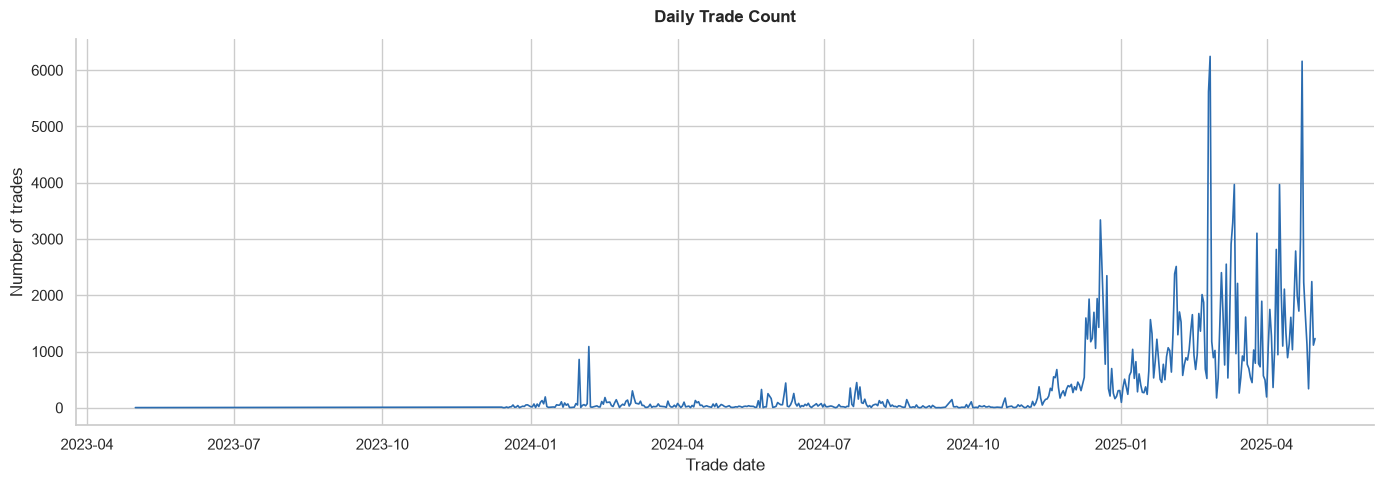

In [24]:
daily_trade_count = eda_data.groupby("trade_date").size()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    daily_trade_count.index,
    daily_trade_count.values,
    color=PRIMARY_COLOR,
    linewidth=1.2,
)
finish_plot("Daily Trade Count", "Trade date", "Number of trades")

**Observation:** Across 480 active dates, the median is 67.5 trades per day and the mean is 440.05, reflecting several activity spikes. The highest recorded day is 25 February 2025 with 6,246 trades.

## Trader Performance

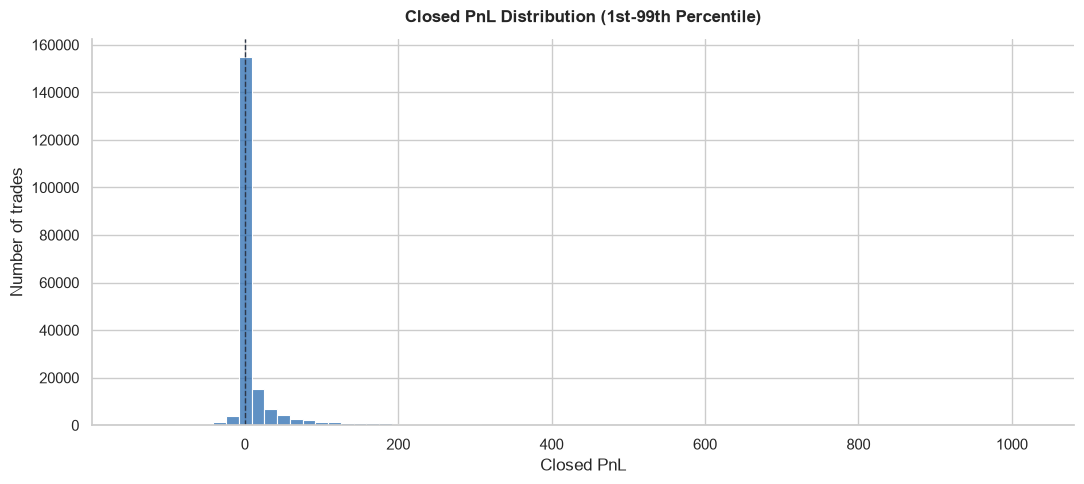

In [25]:
pnl_lower, pnl_upper = eda_data["closed_pnl"].quantile([0.01, 0.99])
central_pnl = eda_data.loc[
    eda_data["closed_pnl"].between(pnl_lower, pnl_upper),
    "closed_pnl",
]
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(central_pnl, bins=70, color=PRIMARY_COLOR, ax=ax)
ax.axvline(0, color="#2D3748", linestyle="--", linewidth=1)
finish_plot(
    "Closed PnL Distribution (1st-99th Percentile)",
    "Closed PnL",
    "Number of trades",
)

**Observation:** The median Closed PnL is 0 and the 75th percentile is 5.79. The central 98% shown spans approximately -140.77 to 1,023.32; the full data extends from -117,990.10 to 135,329.09.

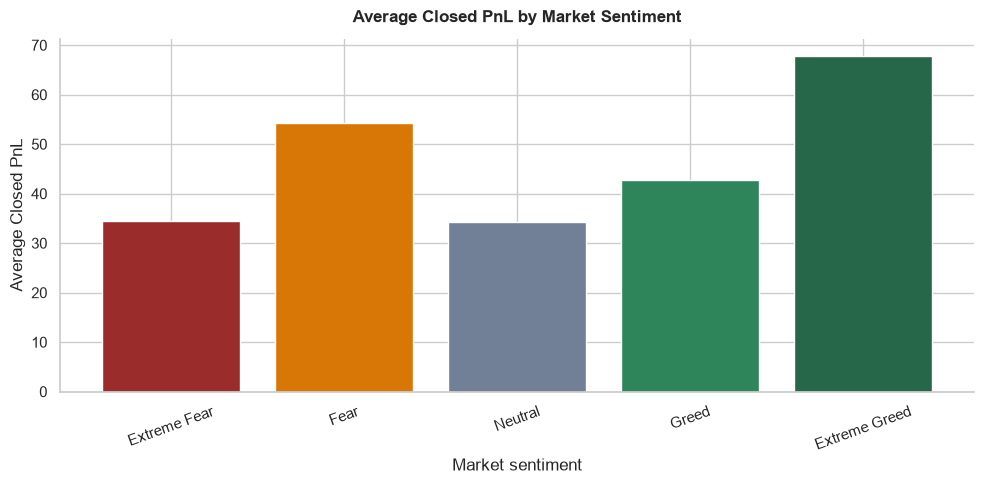

In [26]:
sentiment_data = eda_data.dropna(subset=["fear_greed_classification"])
average_pnl_by_sentiment = (
    sentiment_data.groupby("fear_greed_classification")["closed_pnl"]
    .mean()
    .reindex(SENTIMENT_ORDER)
)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    average_pnl_by_sentiment.index,
    average_pnl_by_sentiment.values,
    color=SENTIMENT_COLORS,
)
ax.tick_params(axis="x", rotation=20)
finish_plot(
    "Average Closed PnL by Market Sentiment",
    "Market sentiment",
    "Average Closed PnL",
)

**Observation:** Average Closed PnL is highest during Extreme Greed (67.89), followed by Fear (54.29). Neutral has the lowest average (34.31) among the five sentiment groups.

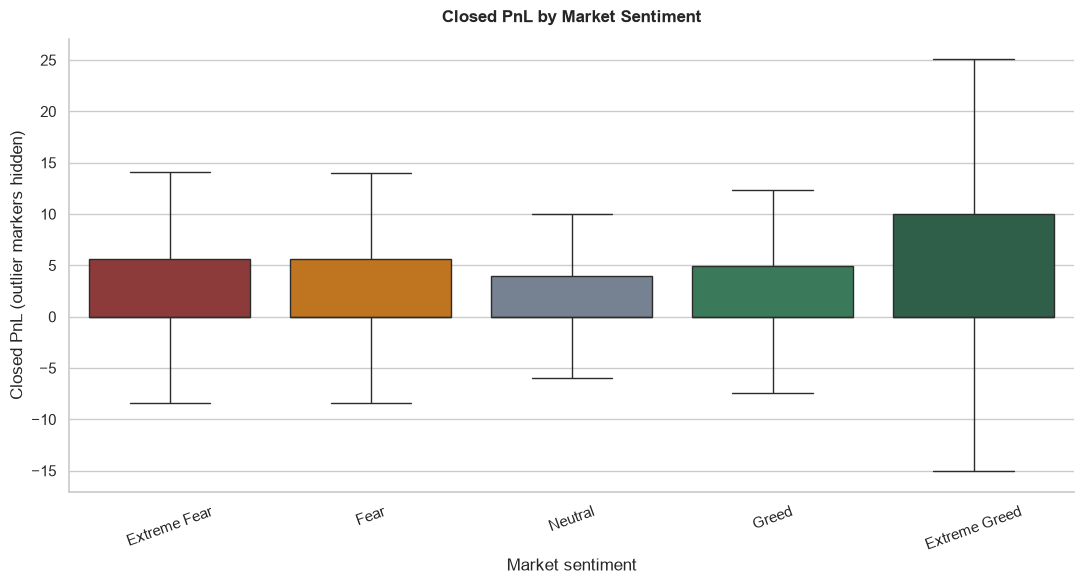

In [27]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=sentiment_data,
    x="fear_greed_classification",
    y="closed_pnl",
    order=SENTIMENT_ORDER,
    hue="fear_greed_classification",
    palette=SENTIMENT_PALETTE,
    showfliers=False,
    legend=False,
    ax=ax,
)
ax.tick_params(axis="x", rotation=20)
finish_plot(
    "Closed PnL by Market Sentiment",
    "Market sentiment",
    "Closed PnL (outlier markers hidden)",
)

**Observation:** Every sentiment group has a median Closed PnL of 0. Their upper quartiles range from 4.00 in Neutral to 10.03 in Extreme Greed; outlier markers are hidden only to keep the boxes readable.

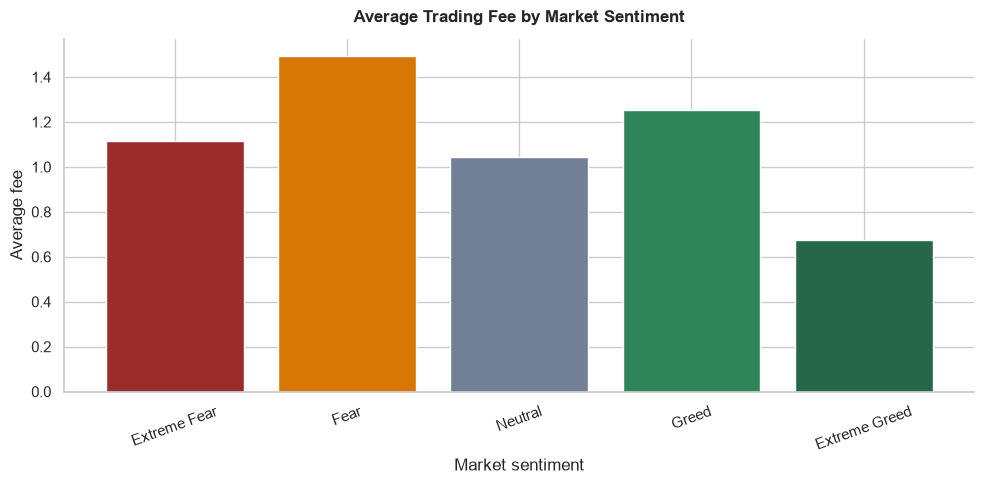

In [28]:
average_fee_by_sentiment = (
    sentiment_data.groupby("fear_greed_classification")["fee"]
    .mean()
    .reindex(SENTIMENT_ORDER)
)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    average_fee_by_sentiment.index,
    average_fee_by_sentiment.values,
    color=SENTIMENT_COLORS,
)
ax.tick_params(axis="x", rotation=20)
finish_plot(
    "Average Trading Fee by Market Sentiment",
    "Market sentiment",
    "Average fee",
)

**Observation:** Average fees are highest during Fear (1.50) and lowest during Extreme Greed (0.68). The remaining groups range from 1.04 to 1.25.

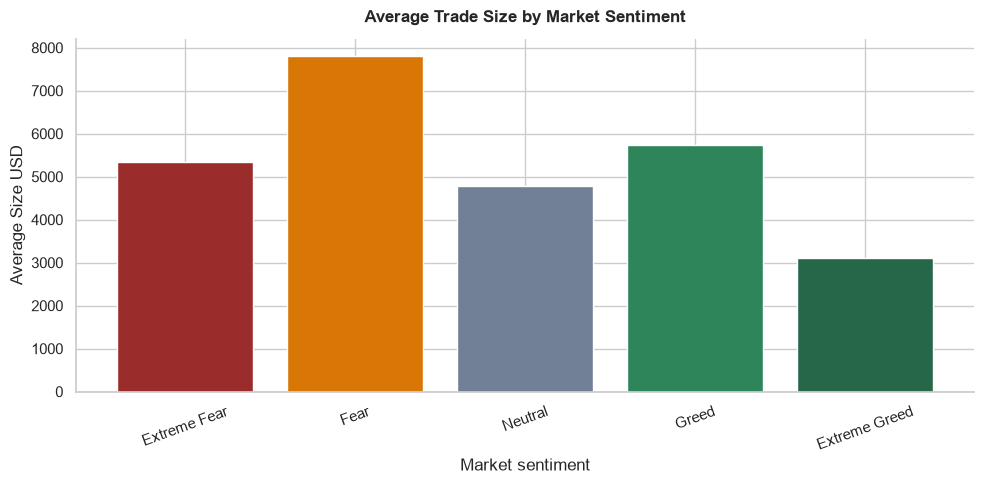

In [29]:
average_size_by_sentiment = (
    sentiment_data.groupby("fear_greed_classification")["size_usd"]
    .mean()
    .reindex(SENTIMENT_ORDER)
)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    average_size_by_sentiment.index,
    average_size_by_sentiment.values,
    color=SENTIMENT_COLORS,
)
ax.tick_params(axis="x", rotation=20)
finish_plot(
    "Average Trade Size by Market Sentiment",
    "Market sentiment",
    "Average Size USD",
)

**Observation:** Fear has the largest average trade size (7,816.11 USD), while Extreme Greed has the smallest (3,112.25 USD).

## Coin Performance

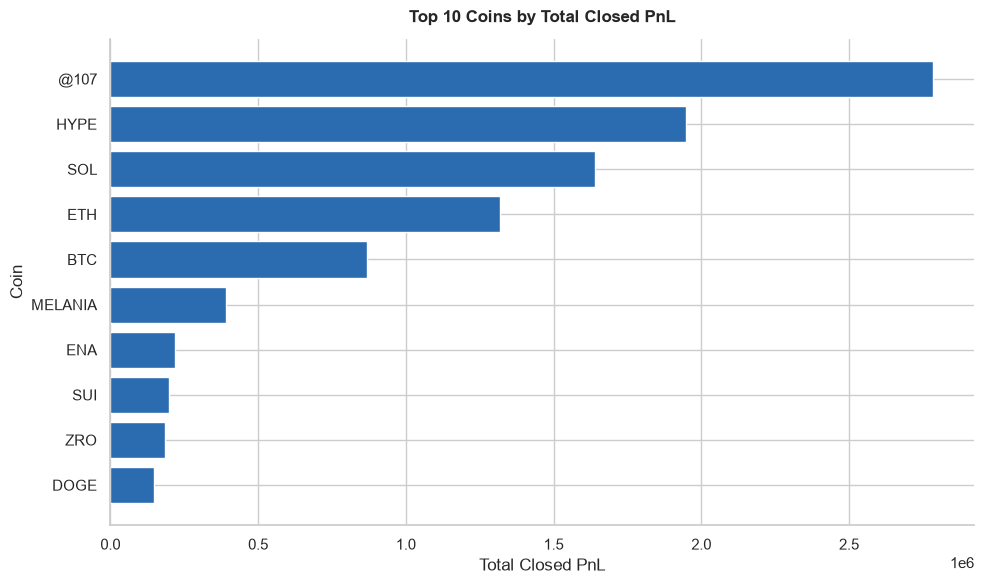

In [30]:
coin_performance = eda_data.groupby("coin").agg(
    total_pnl=("closed_pnl", "sum"),
    average_pnl=("closed_pnl", "mean"),
    trade_count=("closed_pnl", "size"),
)
top_profitable_coins = coin_performance.nlargest(10, "total_pnl").sort_values(
    "total_pnl"
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top_profitable_coins.index,
    top_profitable_coins["total_pnl"],
    color=PRIMARY_COLOR,
)
finish_plot("Top 10 Coins by Total Closed PnL", "Total Closed PnL", "Coin")

**Observation:** @107 has the highest total Closed PnL (2.78 million), followed by HYPE (1.95 million) and SOL (1.64 million).

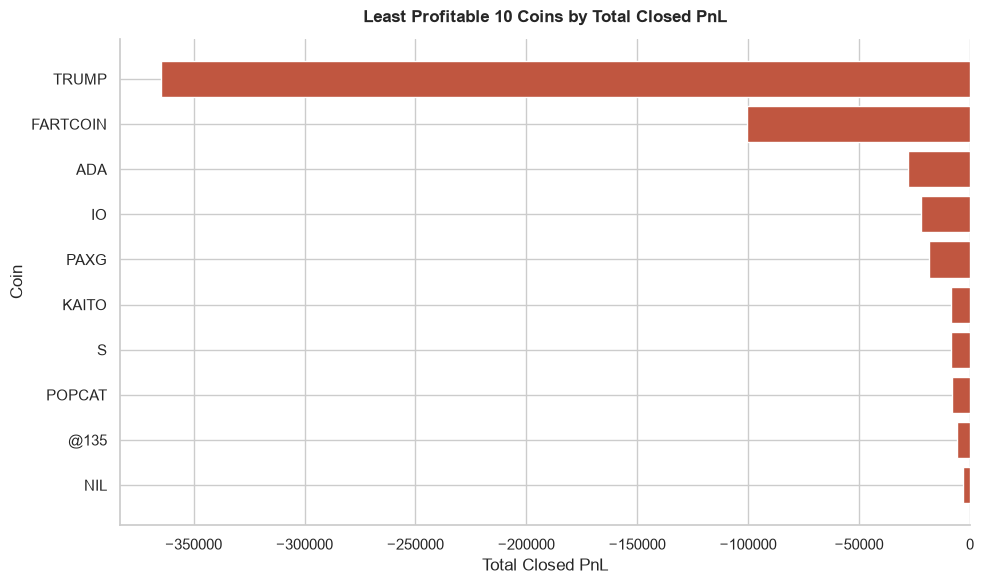

In [31]:
least_profitable_coins = coin_performance.nsmallest(10, "total_pnl").sort_values(
    "total_pnl",
    ascending=False,
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    least_profitable_coins.index,
    least_profitable_coins["total_pnl"],
    color=NEGATIVE_COLOR,
)
finish_plot(
    "Least Profitable 10 Coins by Total Closed PnL",
    "Total Closed PnL",
    "Coin",
)

**Observation:** TRUMP has the lowest total Closed PnL (-364,824.91), followed by FARTCOIN (-100,687.21) and ADA (-28,113.46).

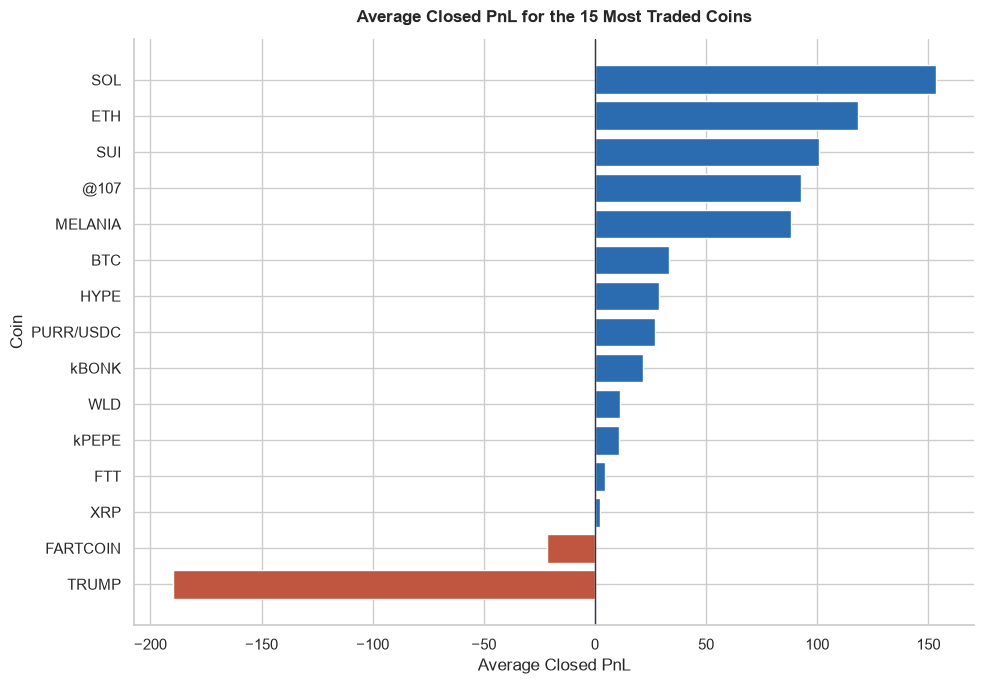

In [32]:
average_pnl_active_coins = (
    coin_performance.nlargest(15, "trade_count")
    .sort_values("average_pnl")
)
bar_colors = [
    NEGATIVE_COLOR if value < 0 else PRIMARY_COLOR
    for value in average_pnl_active_coins["average_pnl"]
]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    average_pnl_active_coins.index,
    average_pnl_active_coins["average_pnl"],
    color=bar_colors,
)
ax.axvline(0, color="#2D3748", linewidth=1)
finish_plot(
    "Average Closed PnL for the 15 Most Traded Coins",
    "Average Closed PnL",
    "Coin",
)

**Observation:** Within the 15 most traded coins, SOL has the highest average Closed PnL (153.36), followed by ETH (118.30). TRUMP (-190.01) and FARTCOIN (-21.65) have negative averages.

## Relationships

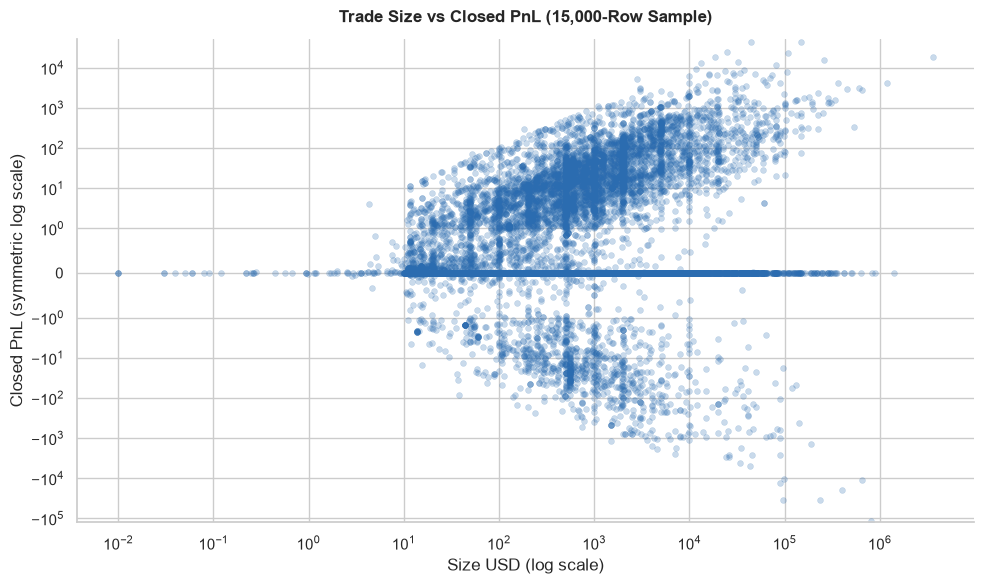

In [33]:
scatter_sample = eda_data.sample(
    n=min(15000, len(eda_data)),
    random_state=42,
)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=scatter_sample.loc[scatter_sample["size_usd"] > 0],
    x="size_usd",
    y="closed_pnl",
    color=PRIMARY_COLOR,
    alpha=0.25,
    s=18,
    edgecolor=None,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("symlog", linthresh=1)
finish_plot(
    "Trade Size vs Closed PnL (15,000-Row Sample)",
    "Size USD (log scale)",
    "Closed PnL (symmetric log scale)",
)

**Observation:** The full dataset's Pearson correlation between Size USD and Closed PnL is 0.124, indicating a weak positive linear association. A fixed 15,000-row sample and symmetric-log axes are used only to keep the dense scatter readable.

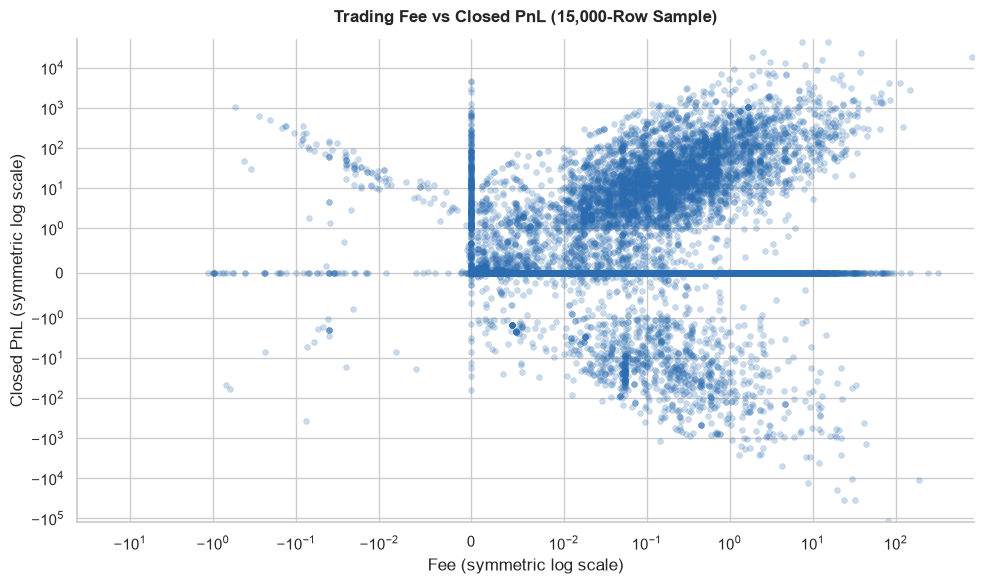

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=scatter_sample,
    x="fee",
    y="closed_pnl",
    color=PRIMARY_COLOR,
    alpha=0.25,
    s=18,
    edgecolor=None,
    ax=ax,
)
ax.set_xscale("symlog", linthresh=0.01)
ax.set_yscale("symlog", linthresh=1)
finish_plot(
    "Trading Fee vs Closed PnL (15,000-Row Sample)",
    "Fee (symmetric log scale)",
    "Closed PnL (symmetric log scale)",
)

**Observation:** Fee and Closed PnL have a weak positive Pearson correlation of 0.084 in the full dataset. The same fixed sample is displayed for legibility.

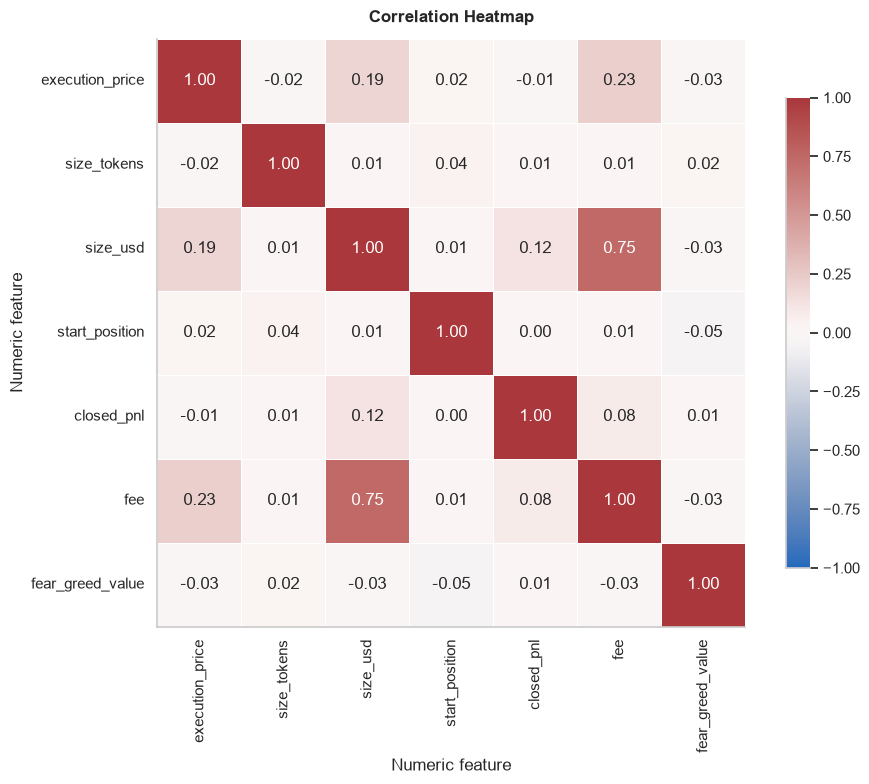

In [35]:
correlation_columns = [
    "execution_price",
    "size_tokens",
    "size_usd",
    "start_position",
    "closed_pnl",
    "fee",
    "fear_greed_value",
]
correlation_matrix = eda_data[correlation_columns].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
finish_plot("Correlation Heatmap", "Numeric feature", "Numeric feature")

**Observation:** Size USD and Fee have the strongest displayed correlation (0.746). Closed PnL has weaker correlations with Size USD (0.124) and Fee (0.084), while its correlation with the Fear & Greed value is 0.008.

# 7. Key Findings

- Greed is the most common sentiment on matched trade dates (40.3%).
- HYPE is the most traded coin with 68,005 records (32.2%).
- Buy and sell activity is nearly balanced: 48.62% versus 51.38%.
- Average Closed PnL is highest in Extreme Greed (67.89), but every sentiment group has a median of zero.
- Closed PnL has weak correlations with trade size (0.124), fee (0.084), and sentiment value (0.008).

# 8. Limitations

- Daily sentiment cannot capture intraday changes.
- The 32-account sample may not represent the wider market.
- Closed PnL is highly skewed, and six trades lack sentiment data.
- External indicators are absent; this exploratory analysis does not establish causation.

# 9. Conclusion

The project preserves all 211,224 trades and matches sentiment to 211,218. It identifies descriptive differences across sentiment and coins, but the weak sentiment-PnL correlation and data limitations do not support causal or predictive claims.